

STEP 1: DATA CLEANING AND PREPARATION




1.1: import libraries and Load the dataset


In [1]:
import pandas as pd 

In [6]:
# Load the dataset
df = pd.read_csv('data/all_kindle_review.csv')

In [7]:
# display the first few rows and summary information
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Index           12000 non-null  int64 
 1   asin            12000 non-null  object
 2   helpful         12000 non-null  object
 3   rating          12000 non-null  int64 
 4   reviewText      12000 non-null  object
 5   reviewTime      12000 non-null  object
 6   reviewerID      12000 non-null  object
 7   reviewerName    11962 non-null  object
 8   summary         11998 non-null  object
 9   unixReviewTime  12000 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 937.6+ KB


In [8]:
df.head()

,Index,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000



1.2: Handle the missing values


In [9]:
# drop rows where 'reviewText', 'rating', or 'summary is missing, as these are critical for analysis.
# 'reviewerName' is less critical, so we can fill missing value with "Unknown" or just ignore it for now.
df.dropna(subset=['rating', 'reviewText', 'summary'], inplace=True)
df['reviewrName'] = df['reviewerName'].fillna('Unknown')


1.3: Fix Data Types


In [10]:
# Convert 'revieTime' to datetime
df['reviewTime'] = pd.to_datetime(df['reviewTime'])

In [11]:
# Parse 'helpful' column
import ast
df['helpful_votes'] = df['helpful'].apply(lambda x: ast.literal_eval(x)[0])
df['total_votes'] = df['helpful'].apply(lambda x: ast.literal_eval(x)[1])

In [17]:
# Verify Changes
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 11998 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Index           11998 non-null  int64         
 1   asin            11998 non-null  object        
 2   helpful         11998 non-null  object        
 3   rating          11998 non-null  int64         
 4   reviewText      11998 non-null  object        
 5   reviewTime      11998 non-null  datetime64[ns]
 6   reviewerID      11998 non-null  object        
 7   reviewerName    11960 non-null  object        
 8   summary         11998 non-null  object        
 9   unixReviewTime  11998 non-null  int64         
 10  reviewrName     11998 non-null  object        
 11  helpful_votes   11998 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(7)
memory usage: 1.2+ MB
None
   Index        asin  helpful  rating  \
0  11539  B0033UV8HI  [8, 10]       3   
1   5957  B0


1.4: Remove Duplicates


In [14]:
# check for duplicates based on 'reviewID', 'asin', and 'unixReviewTime'
df.drop_duplicates(subset=['reviewerID', 'asin', 'unixReviewTime'], inplace=True)

In [12]:
column_categories = [column for column in df.columns if df[column].dtype == 'object']
number_column = [column for column in df.columns if df[column].dtype !='object']

print('Categorical columns:', column_categories)
print('Numerical columns:', number_column)

Categorical columns: ['asin', 'helpful', 'reviewText', 'reviewerID', 'reviewerName', 'summary', 'reviewrName']
Numerical columns: ['Index', 'rating', 'reviewTime', 'unixReviewTime', 'helpful_votes', 'total_votes']



1.5: Count Unique Values in the Categorical Columns


In [8]:
df[column_categories].nunique()

asin             2114
helpful           393
reviewText      12000
reviewTime       1953
reviewerID       7614
reviewerName     6735
summary         10126
dtype: int64


1.6: Calculate Missing Values as Percentage

// df.insull(): detects missing values, returning boolean DataFrame //


In [9]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

Index             0.00
asin              0.00
helpful           0.00
rating            0.00
reviewText        0.00
reviewTime        0.00
reviewerID        0.00
reviewerName      0.32
summary           0.02
unixReviewTime    0.00
dtype: float64

<!-- Step 6: Drop Irrelevant missing Columns

//
df.drop(columns=[]): drops specified columns form the DataFrame
df.dropna(subset=[]): removes rows where specified columns have missing values
fillna(): Fills missing values with specified value
// -->



STEP 2: EXPLORATORY DATA ANALYSIS




2.1: import libraries and Load the dataset


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Feature engineering for EDA
df['review_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))
df['review_year'] = df['reviewTime'].dt.year


2.2: Distribution of Ratings


/var/folders/y1/3hl03bqs5kl_mn9d5rn7syhc0000gn/T/ipykernel_1754/3931785040.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


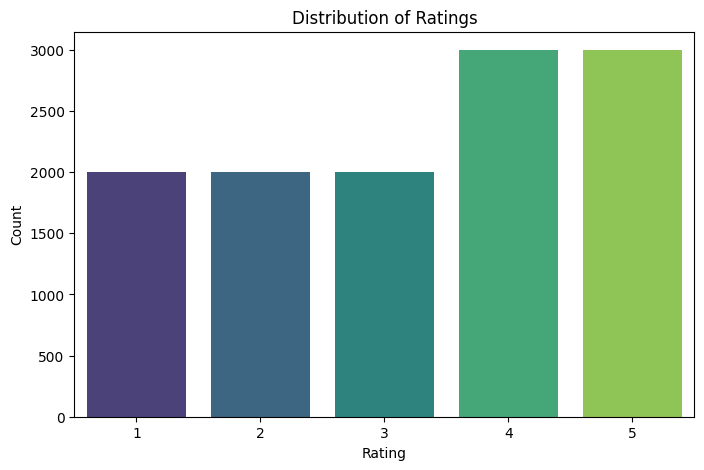

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig('rating_distribution.png')


2.3: Review Length Distribution


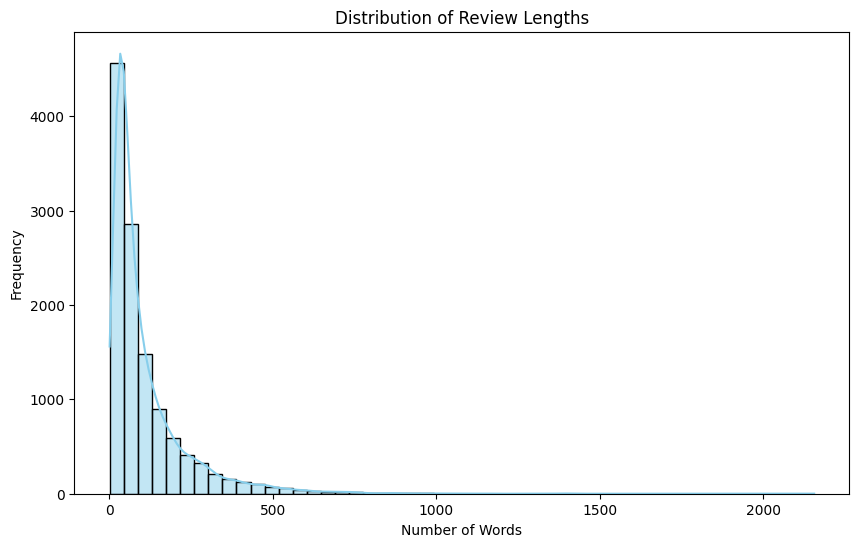

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.savefig('review_length_distribution.png')


2.4: Reviews Over Time (by Year)


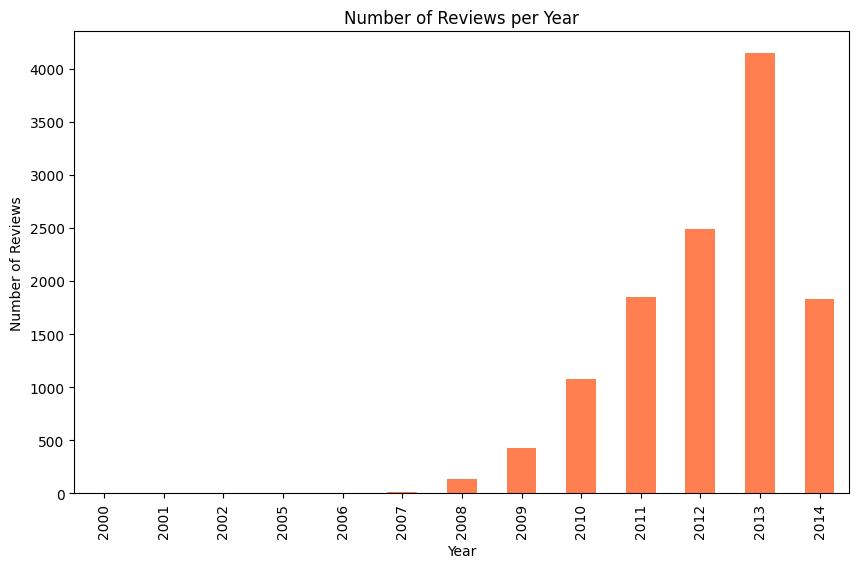

In [28]:
plt.figure(figsize=(10, 6))
df['review_year'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.savefig('review_over_time.png')


2.5: Helpfulness Ratio vs Rating


/var/folders/y1/3hl03bqs5kl_mn9d5rn7syhc0000gn/T/ipykernel_1754/1118378954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='helpfulness_ratio', data=df, palette='Set2')


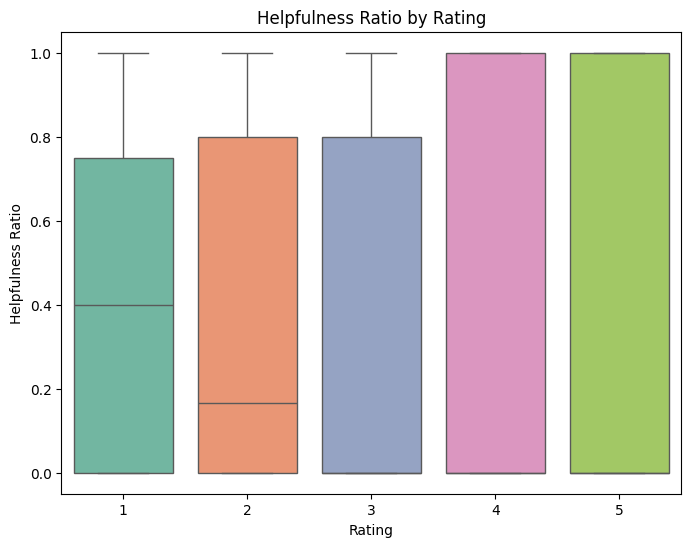

In [33]:
# Create helpfulness ration
df['helpfulness_ratio'] = df.apply(lambda row: row['helpful_votes'] / row['total_votes'] if row['total_votes'] > 0 else 0, axis=1)

plt.figure(figsize=(8, 6))
sns.boxplot(x='rating', y='helpfulness_ratio', data=df, palette='Set2')
plt.title('Helpfulness Ratio by Rating')
plt.xlabel('Rating')
plt.ylabel('Helpfulness Ratio')
plt.savefig('helpfulness_vs_rating.png')



2.6: Calculate descriptive statistics


In [ ]:

desc_stats = df[['rating', 'review_length', 'helpfulness_ratio']].describe()
print(desc_stats)

             rating  review_length  helpfulness_ratio
count  11998.000000   11998.000000       11998.000000
mean       3.249792     109.247041           0.355297
std        1.421632     126.102641           0.431376
min        1.000000       1.000000           0.000000
25%        2.000000      32.000000           0.000000
50%        3.000000      62.000000           0.000000
75%        4.000000     135.000000           0.856092
max        5.000000    2156.000000           1.000000


In [14]:
df.to_csv('data/cleaned_kindle_review.csv', index=False)



STEP 3: DATA SPLITTING::
split the datset into training and testing sets




3.1: import libraires and load the dataset


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [15]:
# Load the cleaned dataset
df = pd.read_csv('data/cleaned_kindle_review.csv')

In [4]:
# Check the current distribution of ratings
print("Rating distribution before mapping:")
print(df['rating'].value_counts())

Rating distribution before mapping:
rating
5    2999
4    2999
3    2000
2    2000
1    2000
Name: count, dtype: int64



3.2: Create a sentiment column based on rating: 1, 2 ->    Negative (0); 3 -> Neutral (1); 4, 5 -> Positive (2)


In [ ]:
def map_sentiment(rating):
    if rating <= 2:
        return 0      #Negative
    elif rating == 3:
        return 1      # Neutral
    else:
        return 2.     # Positive

df['sentiment'] = df['rating'].apply(map_sentiment)

print("\Sentiment distribution:")
print(df['sentiment'].value_counts())

\Sentiment distribution:
sentiment
2.0    5998
0.0    4000
1.0    2000
Name: count, dtype: int64


<>:12: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:12: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
/var/folders/y1/3hl03bqs5kl_mn9d5rn7syhc0000gn/T/ipykernel_5992/2310535222.py:12: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  print("\Sentiment distribution:")


3.3: Split the dataset
X: reviewText (feature), y: sentimet (target)
I keep the other columns in the split dataframes in case they are needed later,
but essentially i'm splitting the rows.

In [ ]:
# Using stratify to ensure the train/test sets have the same proportion of class labels
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['sentiment'])


3.4: Save the split datasets


In [ ]:
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

print("\nTraining set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)
print("\nTraining set sentiment distribution:")
print(train_df['sentiment'].value_counts(normalize=True))
print("\nTesting set sentiment distribution:")
print(test_df['sentiment'].value_counts(normalize=True))


Training set shape: (9598, 17)
Testing set shape: (2400, 17)

Training set sentiment distribution:
sentiment
2.0    0.499896
0.0    0.333403
1.0    0.166701
Name: proportion, dtype: float64

Testing set sentiment distribution:
sentiment
2.0    0.500000
0.0    0.333333
1.0    0.166667
Name: proportion, dtype: float64





STEP 4: CHOOSING AND TRINGING A MODEL:
    
    //tokenization and padding: tf.keras.preprocessing library has been user to convert the text into sequences of integers.//




4.1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import joblib

/Users/peedarp/Library/CloudStorage/OneDrive-UniversityCollegeBirmingham/Desktop/YEAR 3/ARTIFICIAL INTELLIGENCE/Sentiment_System/tfenv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


4.2: Load datasets

In [6]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

4.3: Handle missing value in text

In [7]:
train_df['reviewText'] = train_df['reviewText'].fillna('')
test_df['reviewText'] = test_df['reviewText'].fillna('')

4.4: Tokeniization and Padding
        //i limited the vocabulary to the top 10,000 words and standradized the length of each review to 150 words.//

In [8]:
max_words = 10000    # Top 10,000 words
max_len = 150        # Max length of each review

In [11]:
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['reviewText'])

X_train_seq = tokenizer.texts_to_sequences(train_df['reviewText'])
X_test_seq = tokenizer.texts_to_sequences(test_df['reviewText'])

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

4.5: Prepare Levels

In [12]:
y_train = train_df['sentiment'].values
y_test = test_df['sentiment'].values

4.6: Build the tensorFlow Model

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_words, 64, input_length=max_len),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes: Neg, Neu, Pos
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/Users/peedarp/Library/CloudStorage/OneDrive-UniversityCollegeBirmingham/Desktop/YEAR 3/ARTIFICIAL INTELLIGENCE/Sentiment_System/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


4.7: Train the Model

In [18]:
print("Starting TensorFlow model training.....")
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Starting TensorFlow model training.....
Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5195 - loss: 0.9875 - val_accuracy: 0.5992 - val_loss: 0.9219
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6673 - loss: 0.8106 - val_accuracy: 0.7038 - val_loss: 0.7631
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7314 - loss: 0.6703 - val_accuracy: 0.7133 - val_loss: 0.7136
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7652 - loss: 0.5875 - val_accuracy: 0.7196 - val_loss: 0.6789
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7839 - loss: 0.5398 - val_accuracy: 0.6792 - val_loss: 0.7669
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8099 - loss: 0.4873 - val_accuracy: 0.7454 - val_loss: 0.6542
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8295 - loss: 0.4509 - val_accuracy: 0.7400 - val_loss: 0.6696
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 

4.8: Save the model and tokenizer

In [26]:
model.save('sentiment_tf_model.h5')
joblib.dump(tokenizer, 'tokenizer.pkl')

['tokenizer.pkl']

4.9: Print final training/validation accuracy

In [22]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")

Final Training Accuracy: 0.8721
Final Validation Accuracy: 0.6946




STEP 5: MODEL EVALUATION



5.1: Import libraries

In [12]:
import pandas as pd
import numpy as np
import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

5.2: Load the test data

In [15]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df['reviewText'] = train_df['reviewText'].fillna('')
test_df['reviewText'] = test_df['reviewText'].fillna('')

5.3: Tokenization (using same settings as training)

In [17]:
max_words = 10000
max_len = 150
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['reviewText'])

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(train_df['reviewText']), maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(test_df['reviewText']), maxlen=max_len, padding='post', truncating='post')

y_train = train_df['sentiment'].values
y_test = test_df['sentiment'].values

5.4: Define and train (re-doing it to ensure model is in memory for evaluation)

In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_words, 64, input_length=max_len),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train_pad, y_train, epochs=5, verbose=0)    # 5 epochs is enough for a demo evaluation

/Users/peedarp/Library/CloudStorage/OneDrive-UniversityCollegeBirmingham/Desktop/YEAR 3/ARTIFICIAL INTELLIGENCE/Sentiment_System/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5.5: Evaluation

In [19]:
print("Evaluating on test data....")
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

Evaluating on test data....
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step


5.6: Calculate Metircs

In [20]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive'])

print(f"Test Accuracy: {accuracy: 4f}")
print("\nClassfication Report:\n", class_report)

Test Accuracy:  0.735000

Classfication Report:
               precision    recall  f1-score   support

    Negative       0.69      0.90      0.78       800
     Neutral       0.39      0.17      0.24       400
    Positive       0.83      0.81      0.82      1200

    accuracy                           0.73      2400
   macro avg       0.64      0.63      0.61      2400
weighted avg       0.71      0.73      0.71      2400



5.7: Visualizaiton (Plot Confusion Matrix)

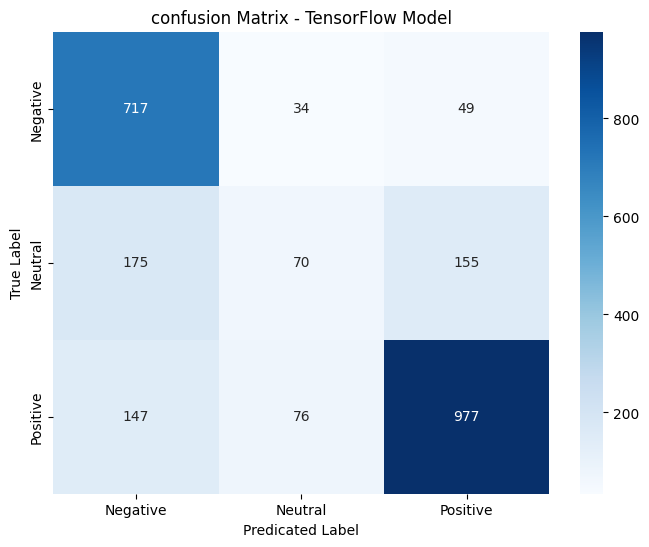

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('confusion Matrix - TensorFlow Model')
plt.xlabel('Predicated Label')
plt.ylabel('True Label')
plt.savefig('confusion_matrix.png')

In [23]:
# Output metrics for the final response
metrics_summary = {
    "accuracy": accuracy,
    "confusion_matrix": conf_matrix.tolist(),
    "class_report": class_report
}
print(metrics_summary)

{'accuracy': 0.735, 'confusion_matrix': [[717, 34, 49], [175, 70, 155], [147, 76, 977]], 'class_report': '              precision    recall  f1-score   support\n\n    Negative       0.69      0.90      0.78       800\n     Neutral       0.39      0.17      0.24       400\n    Positive       0.83      0.81      0.82      1200\n\n    accuracy                           0.73      2400\n   macro avg       0.64      0.63      0.61      2400\nweighted avg       0.71      0.73      0.71      2400\n'}


In [28]:
#saving
model.save('sentiment_tf_model.keras')
joblib.dump(tokenizer, 'tokenizer.pkl')

['tokenizer.pkl']